Missing values before handling:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after handling:
 0
Total NaNs in X: 0
Total NaNs in y: 0


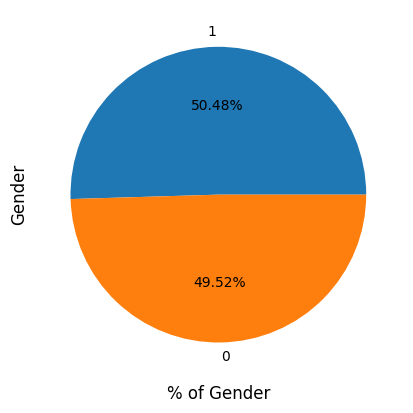

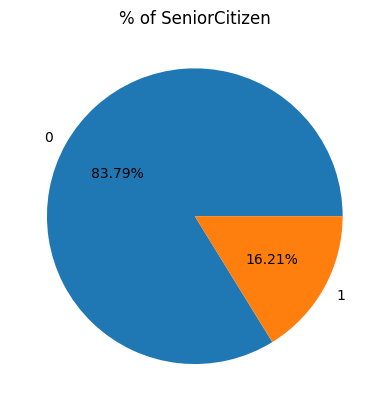

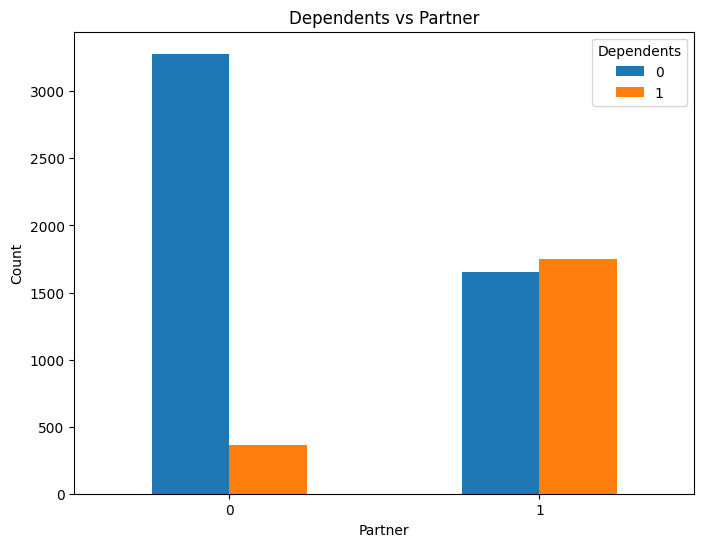

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


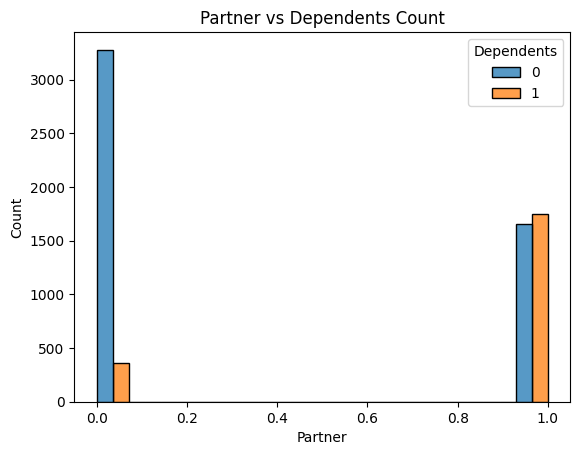

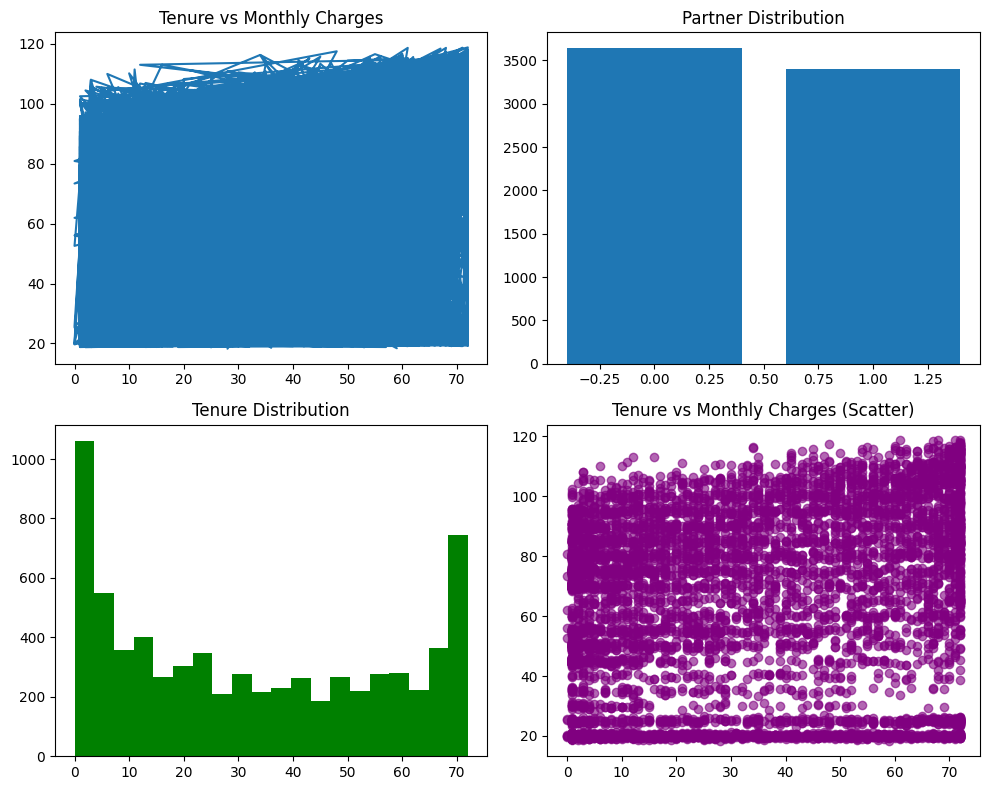

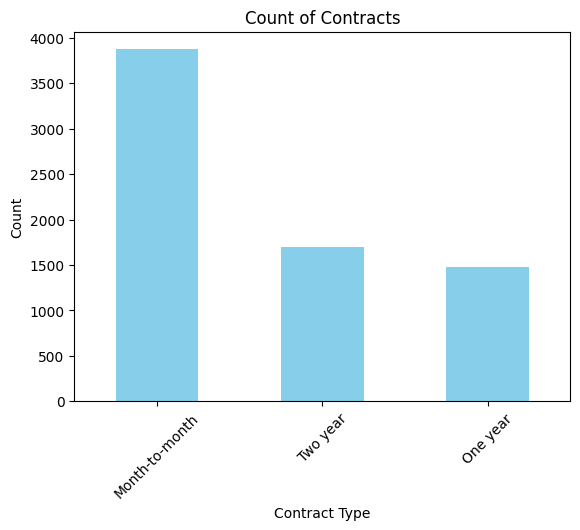

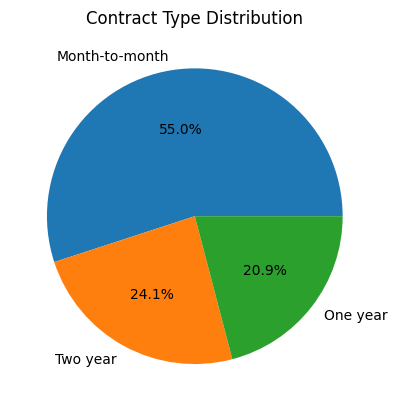

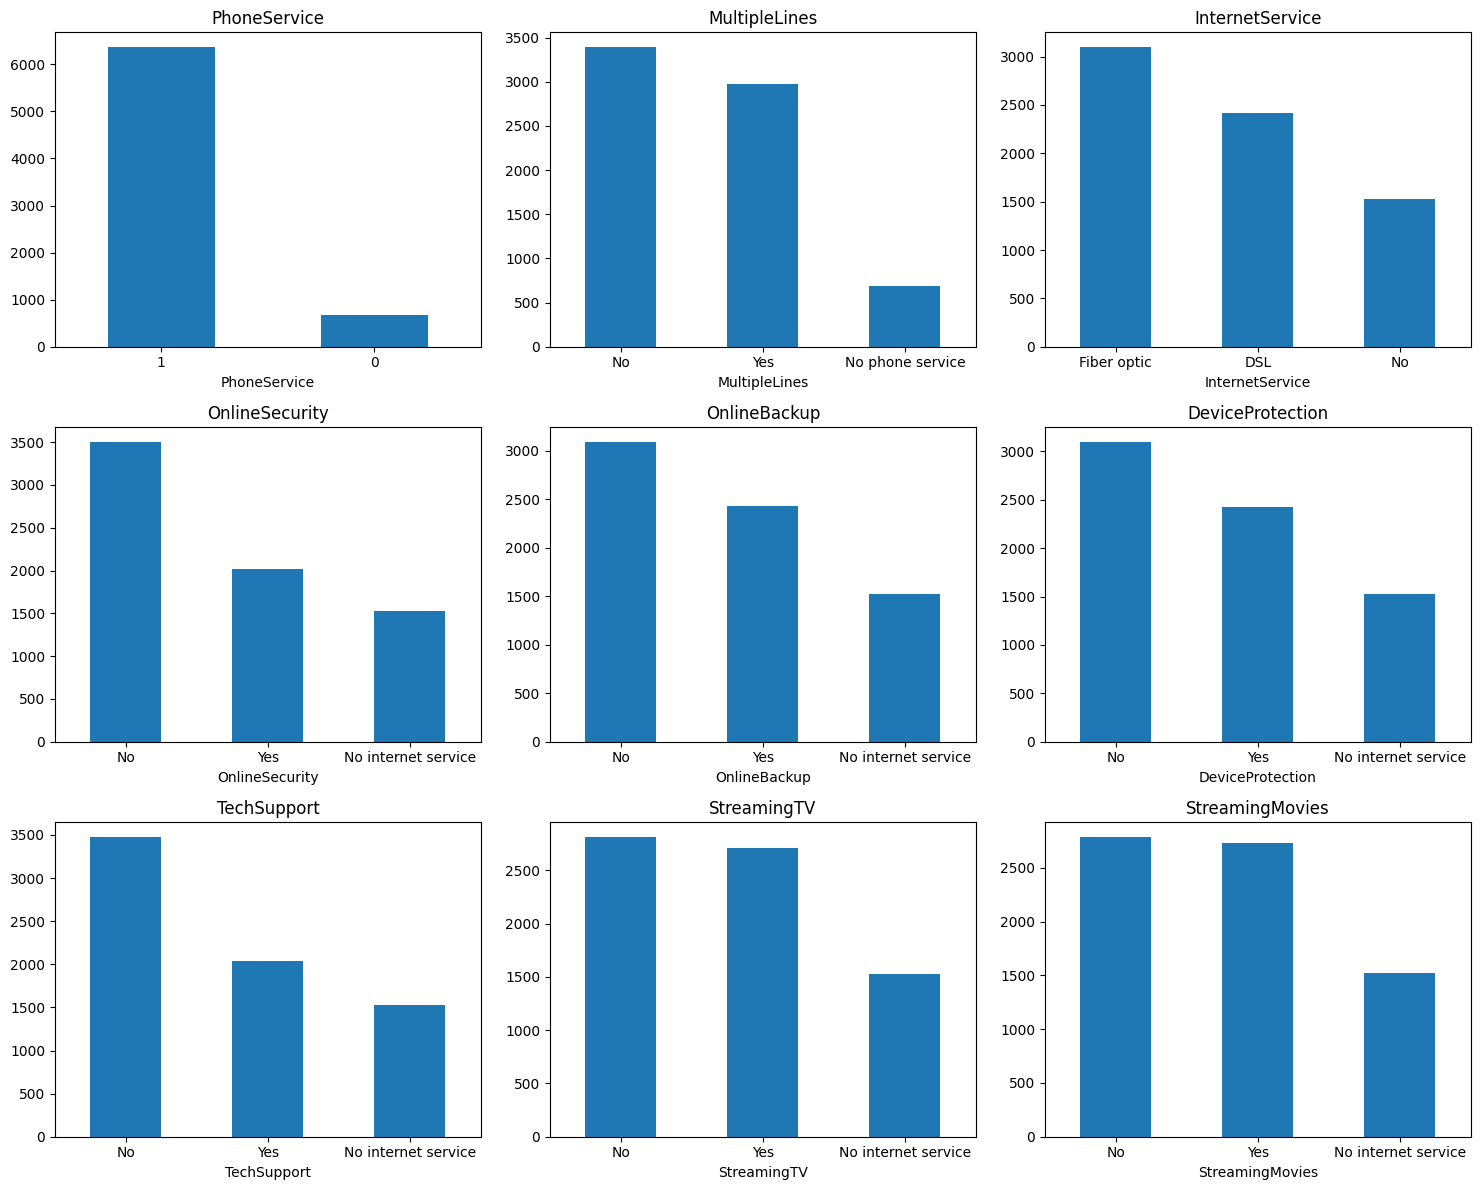

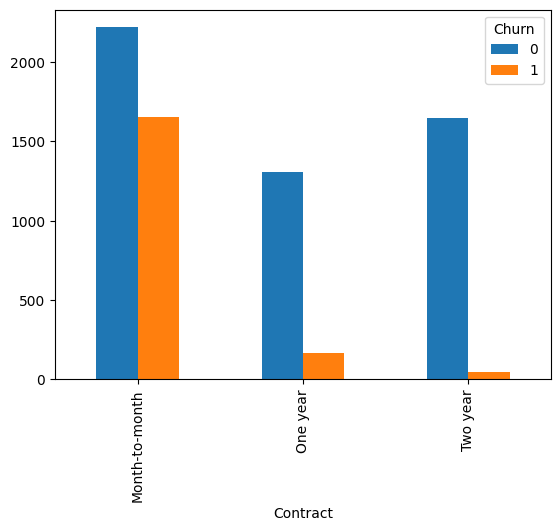

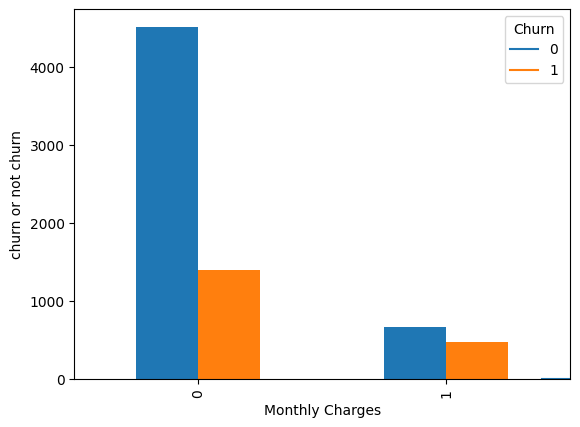

=== Logistic Regression ===
Accuracy: 0.7842
ROC-AUC: 0.8308

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.96      0.87      1035
           1       0.72      0.30      0.43       374

    accuracy                           0.78      1409
   macro avg       0.76      0.63      0.65      1409
weighted avg       0.77      0.78      0.75      1409


=== Random Forest ===
Accuracy: 0.7999
ROC-AUC: 0.8334
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


=== Support Vector Machine ===
Accuracy: 0.7601
ROC-AUC: 0.826
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      1035
           1       0.75      0.

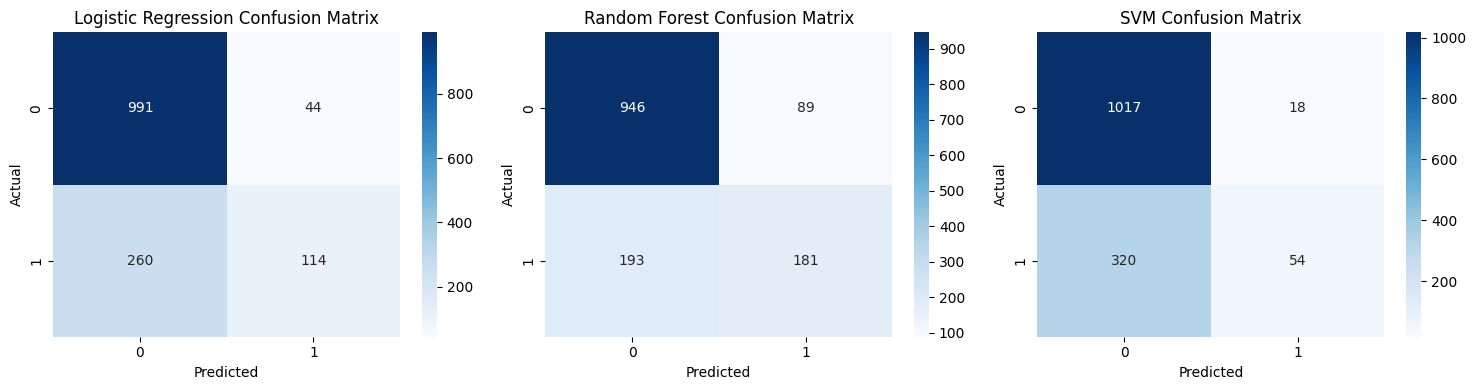

Fitting 2 folds for each of 20 candidates, totalling 40 fits

=== 🏆 Best Parameters from RandomizedSearchCV ===
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}

=== Random Forest (Tuned) ===
Accuracy: 0.8005677785663591
ROC-AUC: 0.8409581751013977

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.46      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


df=pd.read_csv("E:\Telco-Customer-Churn.csv")  # Replace with your path

# 🧹 HANDLE MISSING VALUES
# -------------------------------------------------------

# Convert TotalCharges to numeric (some are blank spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#  Check missing values
print("Missing values before handling:\n", df.isnull().sum())

#  Handle missing numeric columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

#  Handle missing categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("\nMissing values after handling:\n", df.isnull().sum().sum())

# Convert TotalCharges to numeric and drop missing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

#  HANDLE OUTLIERS (optional)

Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['TotalCharges'] >= lower_bound) & (df['TotalCharges'] <= upper_bound)]



# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Split into binary and multi-class categorical columns
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
multi_class_cols = [col for col in cat_cols if df[col].nunique() > 2]

# Label Encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encode multi-class columns
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[multi_class_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(multi_class_cols))

# Merge encoded columns back
df_final = pd.concat([df.drop(multi_class_cols, axis=1), encoded_df], axis=1)


# Drop rows where target is NaN
df_final = df_final.dropna(subset=['Churn'])

# Features and target
X = df_final.drop(columns=['Churn'], errors='ignore')
y = df_final['Churn']

# Fill numeric NaNs in X
num_cols = X.select_dtypes(include=['int64','float64']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Double-check
print("Total NaNs in X:", X.isnull().sum().sum())
print("Total NaNs in y:", y.isnull().sum())
assert len(X) == len(y), "X and y are not aligned!"


fdt_gender = df['gender'].value_counts()

plt.pie(fdt_gender.values, labels=fdt_gender.index, autopct='%.2f%%')
plt.ylabel('Gender', fontsize=12)
plt.xlabel('% of Gender', fontsize=12)
plt.show()


fdt_sc = df['SeniorCitizen'].value_counts()
plt.pie(fdt_sc.values, labels=fdt_sc.index, autopct='%.2f%%')
plt.title('% of SeniorCitizen', fontsize=12)
plt.show()

grouped = df.groupby(['Dependents', 'Partner']).size().unstack()

# Alternative using crosstab
ct = pd.crosstab(df['Partner'], df['Dependents'])

# Plotting the crosstab as a bar chart
ct.plot(kind='bar', figsize=(8,6))
plt.title('Dependents vs Partner')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dependents')
plt.show()

# Descriptive stats of tenure
print(df['tenure'].describe())


import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Partner', hue='Dependents', multiple='dodge')
plt.title('Partner vs Dependents Count')
plt.show()


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#  Line plot - Tenure vs MonthlyCharges
axes[0,0].plot(df['tenure'], df['MonthlyCharges'])
axes[0,0].set_title('Tenure vs Monthly Charges')

#  Bar plot - Partner count
axes[0,1].bar(df['Partner'].value_counts().index, df['Partner'].value_counts().values)
axes[0,1].set_title('Partner Distribution')

#  Histogram - Tenure
axes[1,0].hist(df['tenure'], bins=20, color='green')
axes[1,0].set_title('Tenure Distribution')

#  Scatter plot - Tenure vs MonthlyCharges
axes[1,1].scatter(df['tenure'], df['MonthlyCharges'], alpha=0.6, color='purple')
axes[1,1].set_title('Tenure vs Monthly Charges (Scatter)')

plt.tight_layout()
plt.show()


contract_counts = df['Contract'].value_counts()

# Plot bar chart
contract_counts.plot(kind='bar', color='skyblue')
plt.title('Count of Contracts')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#pie chart

plt.pie(contract_counts, labels=contract_counts.index, autopct='%1.1f%%')
plt.title('Contract Type Distribution')
plt.show()



services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create a figure with a 3x3 grid of subplots
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 12))

# Flatten the 3x3 array of axes into a 1D array for easier iteration
axes = axes.flatten()

for i, item in enumerate(services):
  
    ax = df[item].value_counts().plot(kind = 'bar', ax = axes[i], rot = 0)
    ax.set_title(item)



fig.tight_layout() # Improves spacing between subplots



pd.crosstab(df['Contract'],df['Churn']).plot(kind='bar')


pd.crosstab(df['SeniorCitizen'],df['Churn']).plot(kind='bar')

pd.crosstab(df['SeniorCitizen'],df['Churn'],margins=True)


sns.kdeplot(data = df ,x ='MonthlyCharges',hue='Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('churn or not churn')
plt.show()






#  TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  STANDARDIZE NUMERICAL FEATURES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

#  MODEL 2: RANDOM FOREST
# -------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print(classification_report(y_test, y_pred_rf))

#  MODEL 3: SVM

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Support Vector Machine ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_svm), 4))
print(classification_report(y_test, y_pred_svm))


#  CONFUSION MATRIX HEATMAPS

plt.figure(figsize=(15, 4))
models = ['Logistic Regression', 'Random Forest', 'SVM']
preds = [y_pred_log, y_pred_rf, y_pred_svm]

for i, (model, pred) in enumerate(zip(models, preds)):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()



# RANDOMIZED SEARCH CV FOR RANDOM FOREST


from sklearn.model_selection import RandomizedSearchCV

# Define base model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    cv=2,                      # 5-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1,                 # use all CPU cores
    scoring='roc_auc'          # optimize based on ROC-AUC
)

# Fit the random search model
rf_random.fit(X_train_scaled, y_train)

# Best parameters and model
print("\n=== 🏆 Best Parameters from RandomizedSearchCV ===")
print(rf_random.best_params_)

best_rf = rf_random.best_estimator_

# Evaluate on test set
y_pred_rf_best = best_rf.predict(X_test_scaled)
y_pred_prob_rf_best = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest (Tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_rf_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_best))

